In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import joblib

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
X_train = pd.read_csv("../datasets/X_train.csv")
X_test = pd.read_csv("../datasets/X_test.csv")

y_train = pd.read_csv("../datasets/y_train.csv").squeeze()
y_test = pd.read_csv("../datasets/y_test.csv").squeeze()

print(X_train.shape)
print(X_test.shape)

(82, 10)
(21, 10)


In [3]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost":
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "CatBoost":
    CatBoostClassifier(
        verbose=0,
        random_state=42
    )
}

In [4]:
results = []

trained_models = {}

In [5]:
for name, model in models.items():

    print("="*60)
    print(name)
    print("="*60)

    model.fit(X_train, y_train)

    trained_models[name] = model

    predictions = model.predict(X_test)

    probability = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(y_test, predictions)

    recall = recall_score(y_test, predictions)

    f1 = f1_score(y_test, predictions)

    roc = roc_auc_score(y_test, probability)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

    print(classification_report(
        y_test,
        predictions
    ))

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.50      0.50      0.50         2

    accuracy                           0.90        21
   macro avg       0.72      0.72      0.72        21
weighted avg       0.90      0.90      0.90        21

Decision Tree
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.50      0.67         2

    accuracy                           0.95        21
   macro avg       0.97      0.75      0.82        21
weighted avg       0.95      0.95      0.95        21

Random Forest
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.50      0.67         2

    accuracy                           0.95        21
   macro avg       0.97      0.75      0.82        21
weighted avg       0.95   

In [6]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.904762,0.5,0.5,0.500000,0.973684
1,Decision Tree,0.952381,1.0,0.5,0.666667,0.750000
2,Random Forest,0.952381,1.0,0.5,0.666667,0.973684
3,Gradient Boosting,0.952381,1.0,0.5,0.666667,0.750000
4,XGBoost,0.952381,1.0,0.5,0.666667,0.750000
5,CatBoost,0.952381,1.0,0.5,0.666667,0.973684


In [7]:
results_df.sort_values(
    by="ROC-AUC",
    ascending=False,
    inplace=True
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.952381,1.0,0.5,0.666667,0.973684
0,Logistic Regression,0.904762,0.5,0.5,0.500000,0.973684
5,CatBoost,0.952381,1.0,0.5,0.666667,0.973684
1,Decision Tree,0.952381,1.0,0.5,0.666667,0.750000
3,Gradient Boosting,0.952381,1.0,0.5,0.666667,0.750000
4,XGBoost,0.952381,1.0,0.5,0.666667,0.750000


In [8]:
best_model_name = results_df.iloc[0]["Model"]

print(best_model_name)

Random Forest


In [9]:
best_model = trained_models[best_model_name]

joblib.dump(
    best_model,
    "../models/flood_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [10]:
results_df.to_csv(
    "../models/model_comparison.csv",
    index=False
)

In [11]:
if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature": X_train.columns,

        "Importance": best_model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print(importance)

else:

    print("Feature importance not available.")

       Feature  Importance
6      Jun-Sep    0.488649
3       ANNUAL    0.245307
9          sub    0.116494
8      avgjune    0.043184
2  Cloud Cover    0.036374
7      Oct-Dec    0.024167
4      Jan-Feb    0.020554
5      Mar-May    0.015151
0         Temp    0.007027
1     Humidity    0.003094


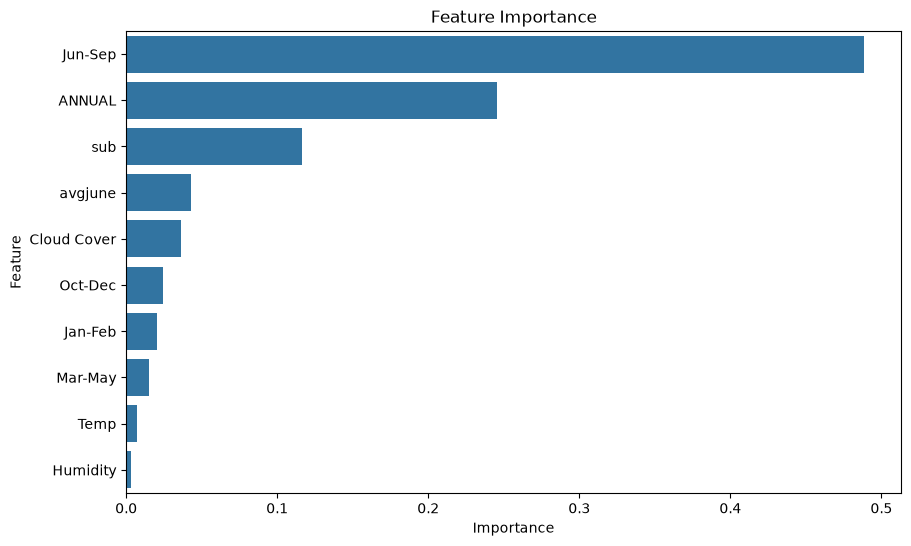

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

if hasattr(best_model, "feature_importances_"):

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature"
    )

    plt.title("Feature Importance")

    plt.show()

In [13]:
print("="*60)

print("MODEL TRAINING COMPLETED")

print("="*60)

print("Best Model :", best_model_name)

print()

print(results_df)

MODEL TRAINING COMPLETED
Best Model : Random Forest

                 Model  Accuracy  Precision  Recall  F1 Score   ROC-AUC
2        Random Forest  0.952381        1.0     0.5  0.666667  0.973684
0  Logistic Regression  0.904762        0.5     0.5  0.500000  0.973684
5             CatBoost  0.952381        1.0     0.5  0.666667  0.973684
1        Decision Tree  0.952381        1.0     0.5  0.666667  0.750000
3    Gradient Boosting  0.952381        1.0     0.5  0.666667  0.750000
4              XGBoost  0.952381        1.0     0.5  0.666667  0.750000
